## Preprocessing

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "workflows"))
from c21_surrogate_training import run_preprocessing

# ── Parameters ───────────────────────────────────────────────────────────────
EDGE_CSV        = "v6_edge_C14_S19999_D20260516"
NODE_CSV        = "v6_node_C12_S19999_D20260516"
BIDIRECTIONAL   = False    # True=240 edges (undirected), False=120 edges (best)
BATCH_SIZE      = 32
DATA_INSPECTION = False    # print per-sample statistics

# ── Run ───────────────────────────────────────────────────────────────────────
pre = run_preprocessing(
    EDGE_CSV, NODE_CSV,
    bidirectional   = BIDIRECTIONAL,
    batch_size      = BATCH_SIZE,
    data_inspection = DATA_INSPECTION,
)

c:\Users\Jasper\Documents\PyEnvs\thesis_home_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Config System loaded successfully, Code running locally from thesis_generative_timber and Data is connected to OneDrive 2.2 - 2.4.

Sample ID column: 'sample_id'
Topology: 120 edges in JSON | 120 rows/sample in CSV | 39 nodes/sample.
Using directed graph: 120 edges.
Final edge count: 120 (unidirectional).
Found 20000 matching samples.
Split: Train=16000 | Val=2000 | Test=2000
Norm stats saved: C:\Users\Jasper\Documents\PyRepo\thesis_generative_timber\02_data_io\norm_stats.pt
Train positive rate: 0.1958 → focal_alpha=0.8042
Dataset: 16000 train | 2000 val | 2000 test. Each: 39 nodes, 120 edges.
Model on cuda | node_dim=10 | edge_dim=9
DataLoaders: 500 train | 63 val | 63 test batches (batch_size=32)
FocalLoss(alpha=0.8042, gamma=2.0)


## Training

In [2]:
from c21_surrogate_training import run_training

# ── Parameters ───────────────────────────────────────────────────────────────
EPOCHS            = 150
LR                = 3e-4
PATIENCE          = 40
LR_FACTOR         = 0.5
LR_PATIENCE       = 10
LR_MIN            = 1e-6
GRAD_CLIP         = 1.0
FOCAL_ALPHA       = 0.5    # override auto-computed alpha (0.5 empirically best)
DEFAULT_THRESHOLD = 0.35   # starting decision threshold for val-set search
MIN_PRECISION     = 0.40   # minimum acceptable precision during threshold search

# ── Run ───────────────────────────────────────────────────────────────────────
train_out = run_training(
    pre,
    epochs            = EPOCHS,
    lr                = LR,
    patience          = PATIENCE,
    lr_factor         = LR_FACTOR,
    lr_patience       = LR_PATIENCE,
    lr_min            = LR_MIN,
    grad_clip         = GRAD_CLIP,
    focal_alpha       = FOCAL_ALPHA,
    default_threshold = DEFAULT_THRESHOLD,
    min_precision     = MIN_PRECISION,
)


FocalLoss(alpha=0.5000, gamma=2.0)  [preprocessing value overridden]

Hyperparameters: epochs=150, lr=3e-04, patience=40, grad_clip=1.0, focal_alpha=0.5, default_threshold=0.35, min_precision=0.4
Checkpoint: C:\Users\Jasper\Documents\PyRepo\thesis_generative_timber\02_data_io\surrogate_v4_checkpoint.pth

Starting training: 150 epochs, early stopping patience=40
----------------------------------------------------------------------
Epoch 005  train=0.048399  val=0.048249  lr=3.00e-04  no_improve=0/40
Epoch 010  train=0.046850  val=0.047251  lr=3.00e-04  no_improve=0/40
Epoch 015  train=0.046402  val=0.046756  lr=3.00e-04  no_improve=0/40
Epoch 020  train=0.046103  val=0.046782  lr=3.00e-04  no_improve=3/40
Epoch 025  train=0.045870  val=0.046238  lr=3.00e-04  no_improve=2/40
Epoch 030  train=0.045776  val=0.046387  lr=3.00e-04  no_improve=1/40
Epoch 035  train=0.045677  val=0.046627  lr=3.00e-04  no_improve=6/40
Epoch 040  train=0.045658  val=0.045932  lr=3.00e-04  no_improve=1/40
Epoch

## Evaluation

Thresholds — val-tuned: 0.350 | max-F1: 0.422 | safety (P>=40%): 0.320
  Saved: eval_fig1_training_dynamics.png


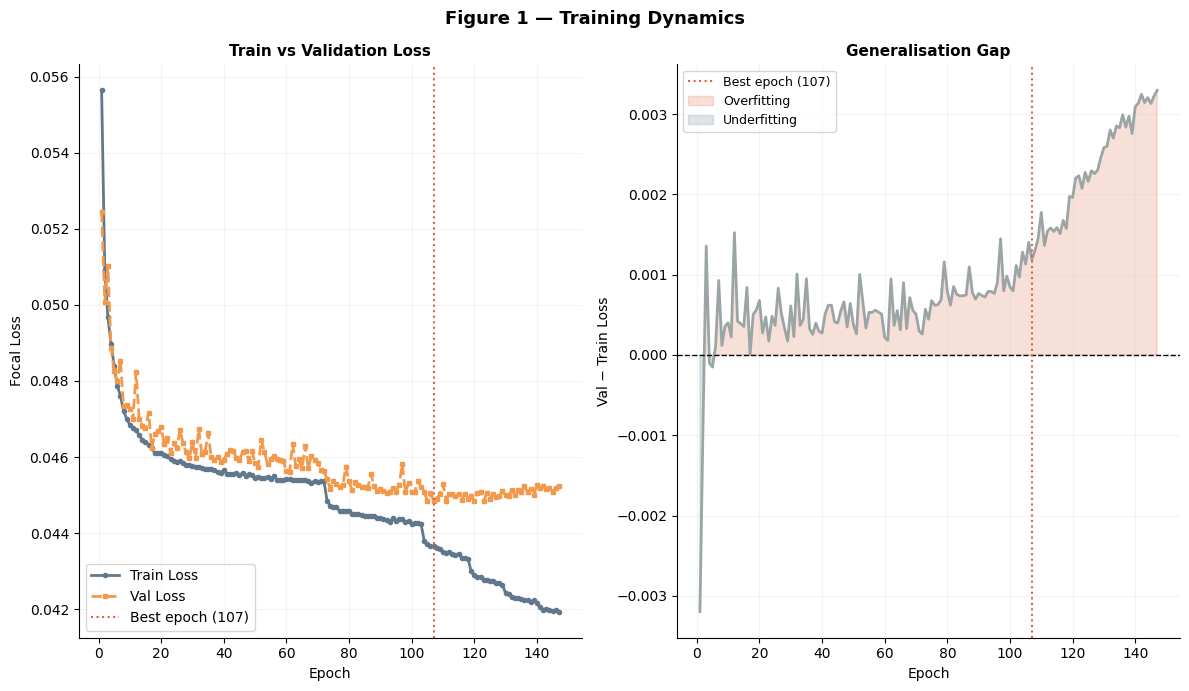

  Saved: eval_fig2_threshold_analysis.png


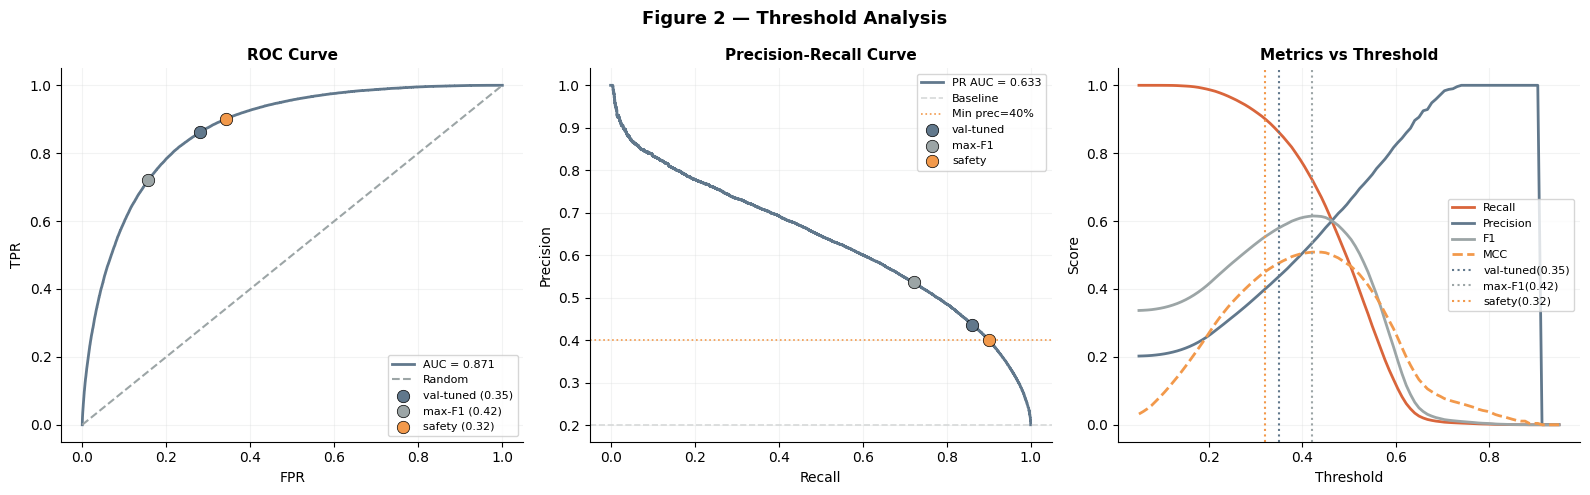

  Saved: eval_fig3_prediction_quality.png


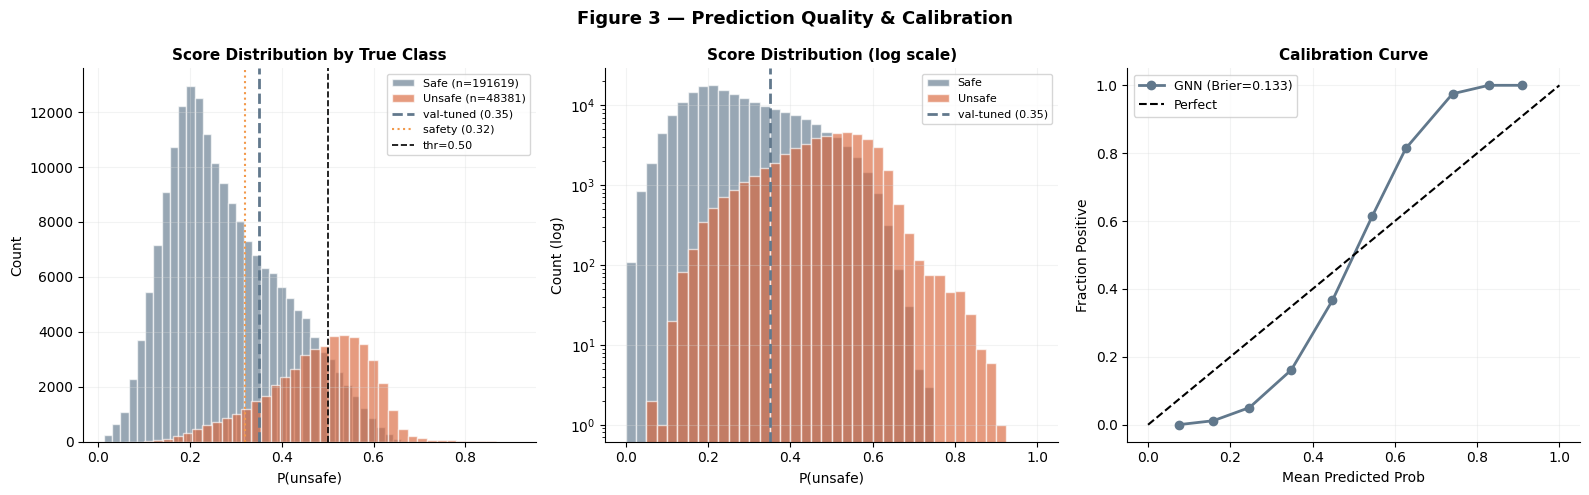

  Saved: eval_fig4_confusion_matrices.png


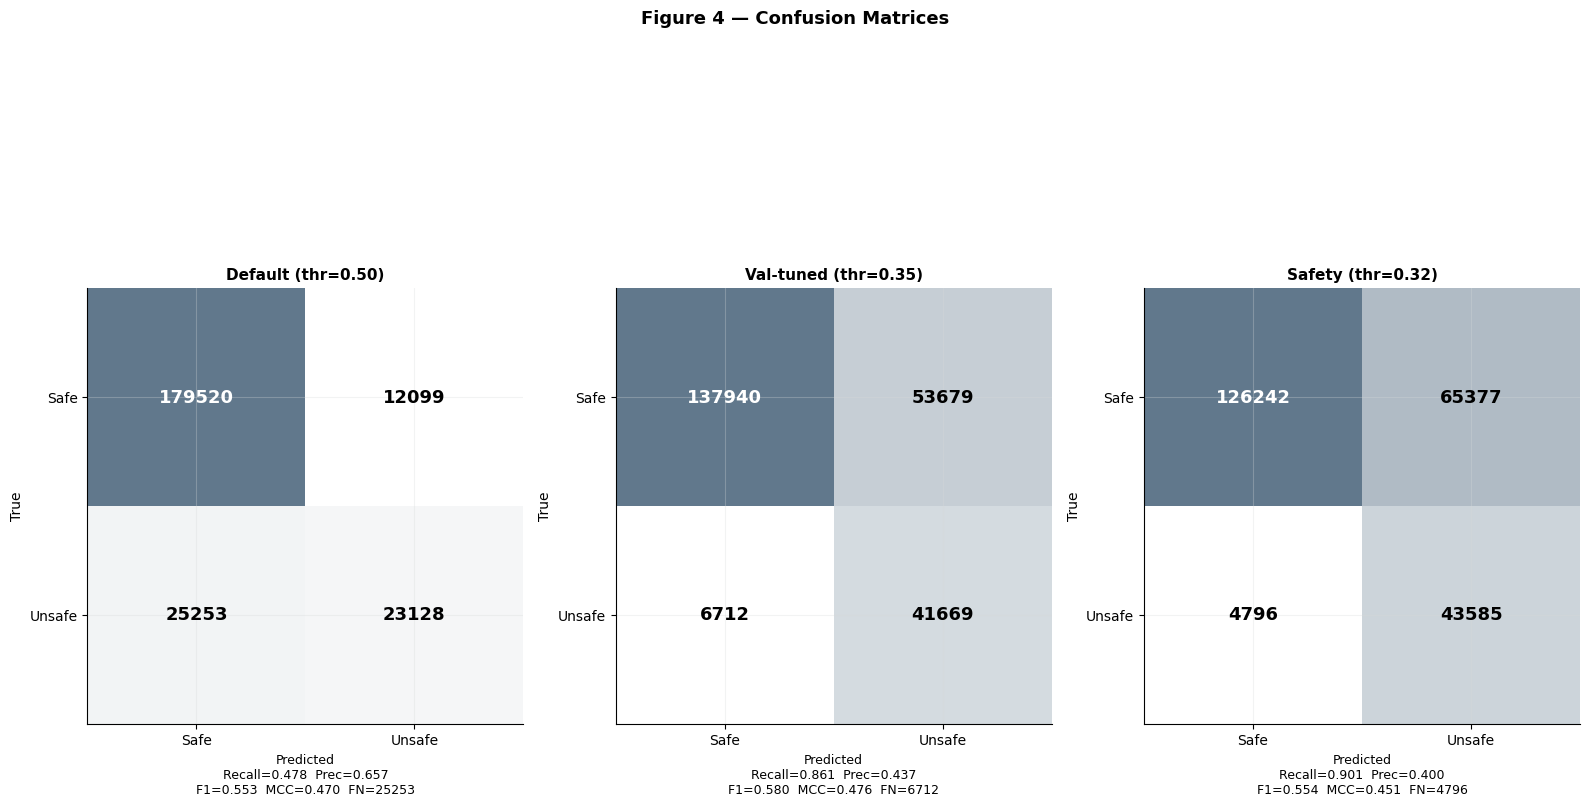

  Saved: eval_fig5_per_member.png


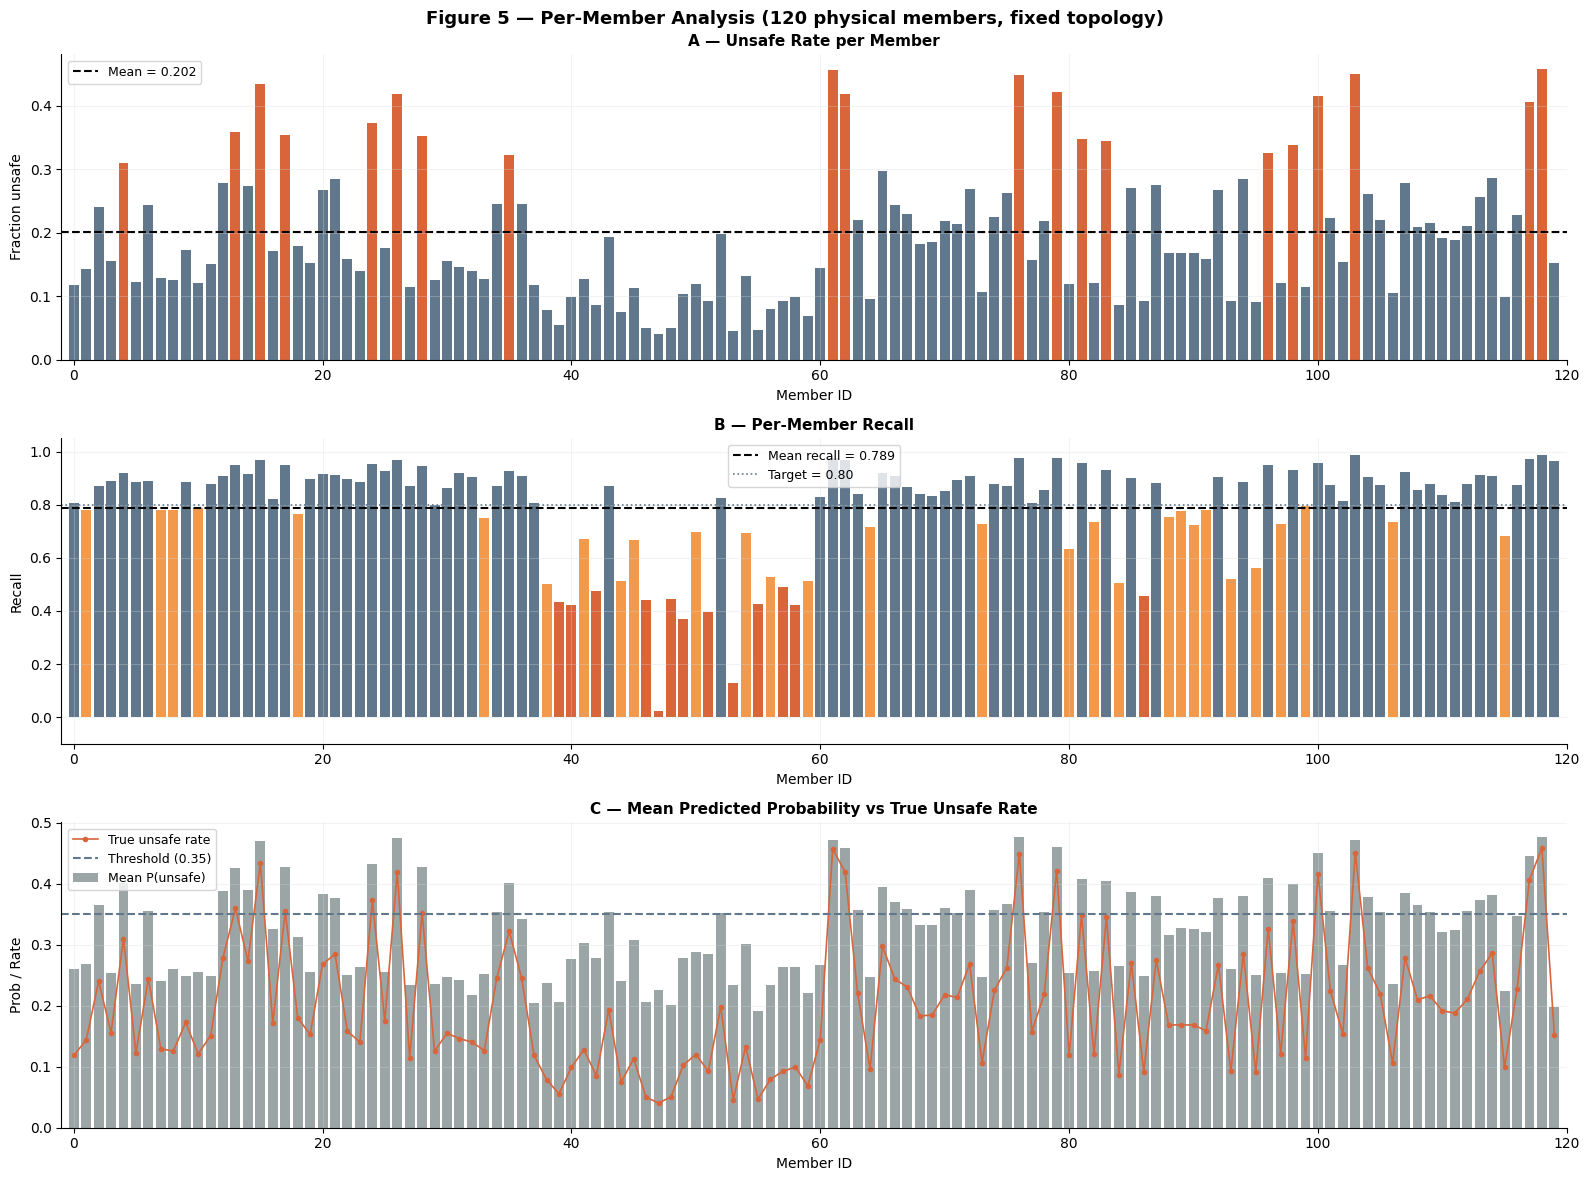


Top 10 hardest members (lowest recall):
  MemberID  UnsafeRate    Recall       FPR
        47       0.041     0.025     0.005
        53       0.046     0.130     0.024
        49       0.103     0.369     0.115
        51       0.093     0.398     0.157
        58       0.100     0.422     0.122
        40       0.099     0.424     0.144
        55       0.047     0.426     0.050
        39       0.056     0.432     0.061
        46       0.050     0.440     0.068
        48       0.051     0.446     0.046

EVALUATION SUMMARY — TrussEdgeSafetyGNN
  Epochs trained: 147  (best: 107)
  ROC AUC: 0.8714  |  PR AUC: 0.6326  |  Brier: 0.1327

  @ Default (thr=0.50):
    Precision=0.6565  Recall=0.4780  F1=0.5532  MCC=0.4704  FN=25253

  @ Val-tuned (thr=0.35):
    Precision=0.4370  Recall=0.8613  F1=0.5798  MCC=0.4764  FN=6712

  @ Safety (thr=0.32):
    Precision=0.4000  Recall=0.9009  F1=0.5540  MCC=0.4510  FN=4796

Evaluation complete. Figures: fig1-fig5  |  Metrics dict: eval_out['metri

In [3]:
from c21_surrogate_training import run_evaluation

# ── Run ───────────────────────────────────────────────────────────────────────
eval_out = run_evaluation(train_out, pre)


## Export

In [4]:
from c21_surrogate_training import run_export

# ── Run ───────────────────────────────────────────────────────────────────────
export_out = run_export(pre, train_out, eval_out)
print("Saved to:", export_out["models_dir"])
print("Files:")
for f in export_out["all_files"]:
    print(" ", f)


Artifact stem: ID20260516_132646_LR3e-04_EP147_BS32_FA0.50_ROC0.871
Checkpoint copied:   ID20260516_132646_LR3e-04_EP147_BS32_FA0.50_ROC0.871.pth
Norm stats copied:   ID20260516_132646_LR3e-04_EP147_BS32_FA0.50_ROC0.871_norm_stats.pt
Topology copied:     ID20260516_132646_LR3e-04_EP147_BS32_FA0.50_ROC0.871_edge_index.json
Scalers JSON saved:  ID20260516_132646_LR3e-04_EP147_BS32_FA0.50_ROC0.871_scalers.json
Inference config:    ID20260516_132646_LR3e-04_EP147_BS32_FA0.50_ROC0.871_inference_config.json
Metrics JSON saved:  metrics.json
Training report:     ID20260516_132646_LR3e-04_EP147_BS32_FA0.50_ROC0.871_training_report.txt
Figure saved:        ID20260516_132646_LR3e-04_EP147_BS32_FA0.50_ROC0.871_eval_fig1_training_dynamics.png
Figure saved:        ID20260516_132646_LR3e-04_EP147_BS32_FA0.50_ROC0.871_eval_fig2_threshold_analysis.png
Figure saved:        ID20260516_132646_LR3e-04_EP147_BS32_FA0.50_ROC0.871_eval_fig3_prediction_quality.png
Figure saved:        ID20260516_132646_LR3e-0